# 06. Model Training - Baseline Comparison
Trong bước này, chúng ta sẽ xây dựng các mô hình phân loại Spam cơ bản (Baseline) để thiết lập một tiêu chuẩn hiệu năng. Chúng ta sẽ so sánh các thuật toán phổ biến như Naive Bayes, Logistic Regression và Random Forest.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
import joblib
import os

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

## 1. Load Dữ liệu
Chúng ta sử dụng file `05_model_ready.csv` đã được làm sạch hoàn toàn.

In [2]:
df = pd.read_csv('../data/processed/05_model_ready.csv').fillna('')
print(f"Loaded dataset: {df.shape[0]} rows")
print(f"Label distribution:\n{df['label'].value_counts(normalize=True) * 100}")

Loaded dataset: 33664 rows
Label distribution:
label
1    51.00701
0    48.99299
Name: proportion, dtype: float64


## 2. Phân tách Train/Test
Sử dụng 80% dữ liệu để huấn luyện và 20% để đánh giá.

In [3]:
X = df['cleaned_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 26931
Test size: 6733


## 3. Huấn luyện các mô hình Baseline
Chúng ta sẽ sử dụng Pipeline của Scikit-Learn để kết hợp TF-IDF và Classifier.

In [4]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Collect metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    trained_models[name] = pipeline

results_df = pd.DataFrame(results)
results_df

Training Naive Bayes...
Training Logistic Regression...
Training Random Forest...


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.980692,0.963524,1.0,0.981423
1,Logistic Regression,0.998515,0.997096,1.0,0.998546
2,Random Forest,0.999851,0.999709,1.0,0.999854


## 4. So sánh hiệu năng
Với bài toán Spam, chúng ta ưu tiên **Precision** (để tránh nhầm lẫn email quan trọng là rác) và **Recall** (để bắt được nhiều rác nhất).

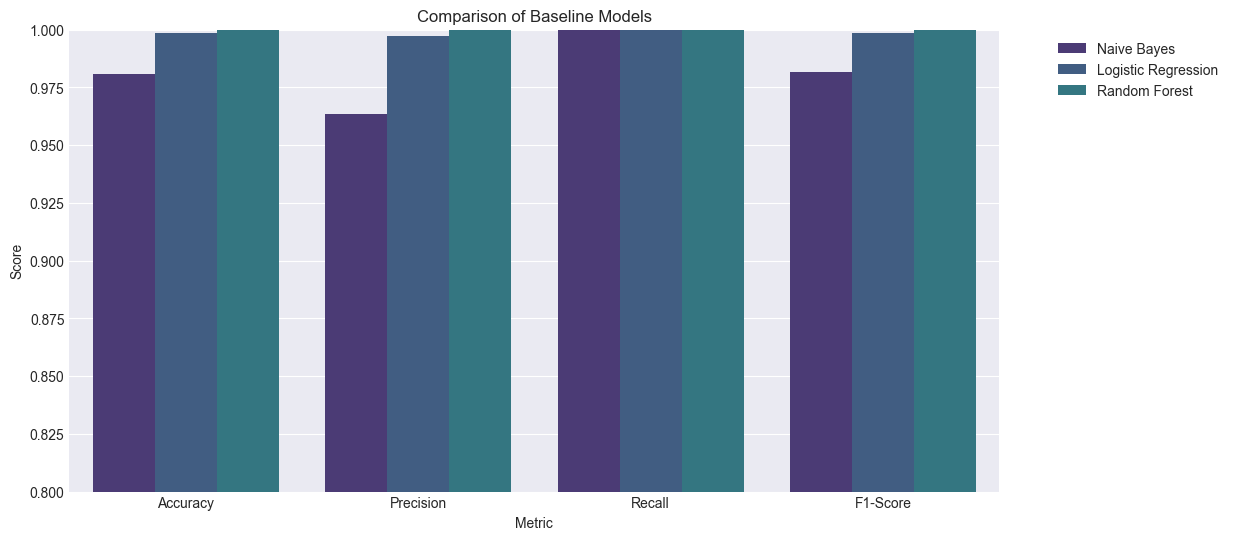

In [5]:
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")
plt.title("Comparison of Baseline Models")
plt.ylim(0.8, 1.0) # Zoom in to see differences
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 5. Chi tiết Confusion Matrix
Xem xét kỹ lỗi False Positive và False Negative của mô hình tốt nhất (thường là Naive Bayes hoặc Logistic cho văn bản).

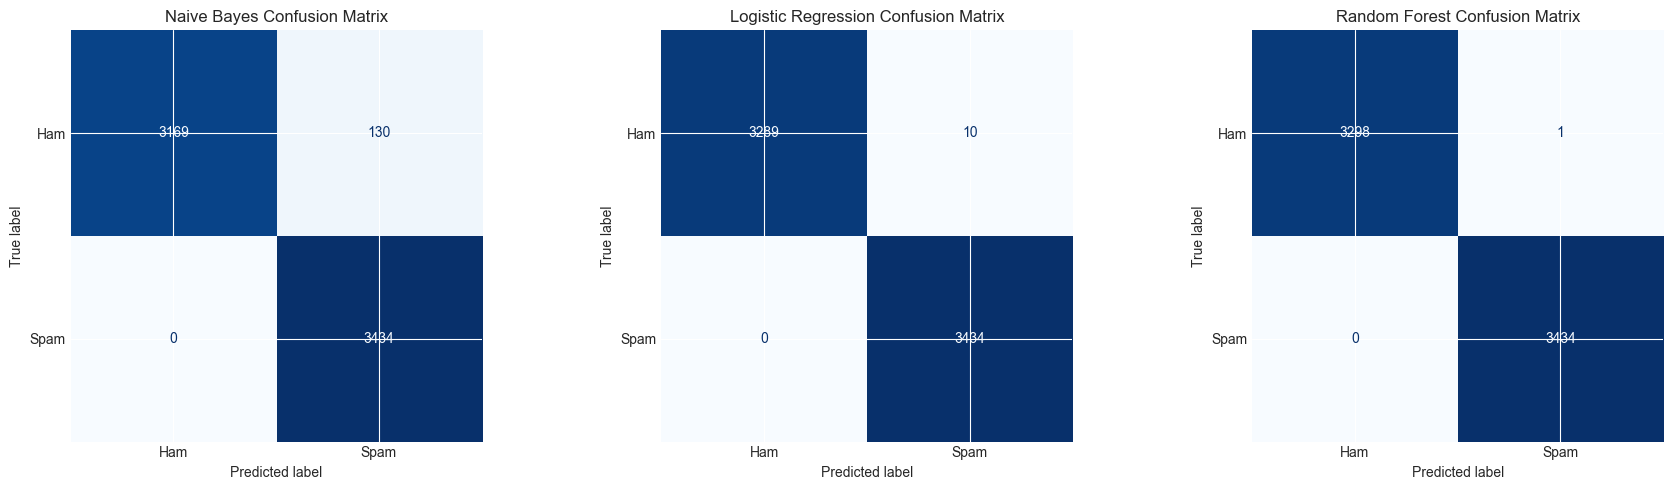

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pipeline) in enumerate(trained_models.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{name} Confusion Matrix")
    
plt.tight_layout()
plt.show()

## 6. Lưu Model Tốt Nhất
Chúng ta sẽ chọn model có F1-Score cao nhất để lưu lại.

In [7]:
best_model_name = results_df.loc[results_df['F1-Score'].idxmax()]['Model']
best_pipeline = trained_models[best_model_name]

model_dir = '../models'
if not os.path.exists(model_dir): os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'baseline_spam_model.pkl')
joblib.dump(best_pipeline, model_path)

print(f"Best Model: {best_model_name}")
print(f"Model saved to: {model_path}")

Best Model: Random Forest
Model saved to: ../models\baseline_spam_model.pkl
